# PINN vs a plain network: a body thrown upward

Twenty noisy height measurements of `h(t) = h0 + v0 t - g t²/2` (noise σ =
1.5 m). A plain network fits the data; a PINN also penalizes violating the
equation of motion at 50 collocation points. How much physics, and in what
form?

The concise counterpart of `pinn_vs_nn_comparison.ipynb`, kept as it was.
Everything is `src/gravity/pinn.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core import viz_style as vs
import plots

vs.use_style()
from gravity.pinn import Throw, sweep

## Two ways to put the physics in

The original notebook used the **velocity** residual `dh/dt = v0 - g t`. It
contains this throw's true v0 as well as g, so it tells the network the
answer's derivative. The **acceleration** residual `d²h/dt² = -g` knows only
gravity; v0 and h0 have to come from the data. Both are swept over the
physics weight λ.

In [2]:
throw = Throw()
velocity, runs_v = sweep(throw, residual="velocity")
acceleration, runs_a = sweep(throw, residual="acceleration")
velocity.merge(acceleration, on="lambda_ode", suffixes=("_velocity", "_acceleration"))[
    ["lambda_ode", "rmse_vs_truth_velocity", "rmse_vs_truth_acceleration",
     "final_data_loss_acceleration", "noise_variance_acceleration"]].round(4)

,lambda_ode,rmse_vs_truth_velocity,rmse_vs_truth_acceleration,final_data_loss_acceleration,noise_variance_acceleration
0,0.0,1.2095,1.2095,0.1046,2.25
1,0.1,0.2505,0.1089,1.5762,2.25
2,1.0,0.0673,0.0854,1.5935,2.25
3,10.0,0.0619,0.0986,1.5923,2.25
4,100.0,0.0343,1.1819,2.7253,2.25


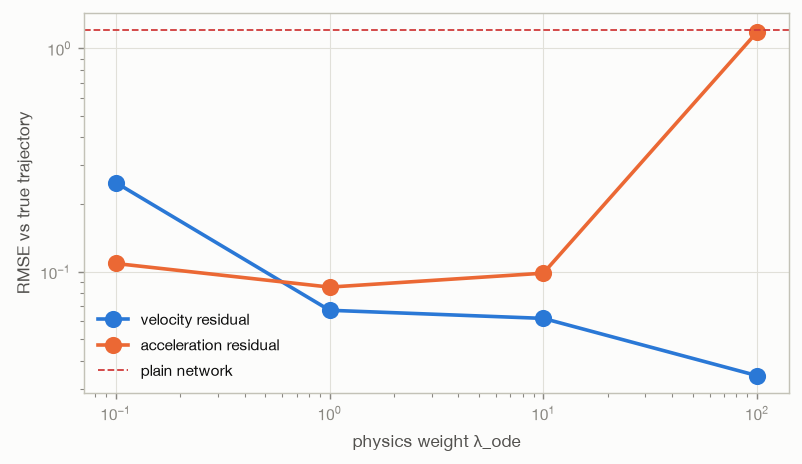

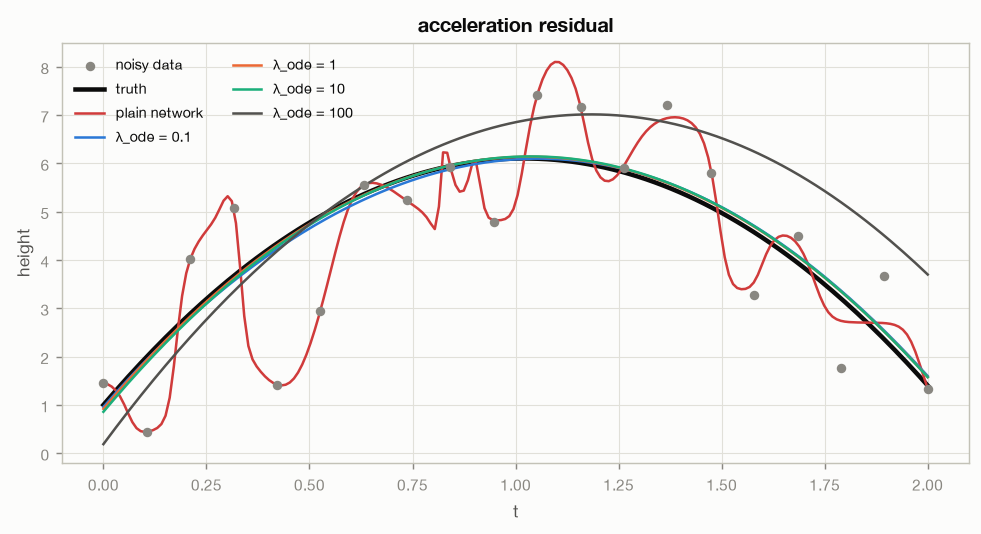

In [3]:
plots.pinn_error_vs_weight(velocity, acceleration);
plots.pinn_fits(throw, runs_a, title="acceleration residual");

**The plain network fits the noise**: its data loss ends near 0.1 against a
noise variance of 2.25, and its error against the true trajectory is ~1.2 m.
Any physics term cures that.

**With the velocity residual, more physics is always better**, down to a few
centimetres - unsurprising, since the residual contains the answer.

**With the acceleration residual there is an optimum** around λ = 1. At
λ = 100 the physics term dominates the loss, the data that pins down v0 and
h0 is ignored, and the error climbs back to the plain network's. That
trade-off is the practical question with PINNs, and the velocity residual
hides it.